In [1]:
import csv
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [2]:
MODEL_DIRS = {
    "fea_2": Path("results/result_single_fea_2"),
    "fea_5": Path("results/result_single_fea_5"),
    "fea_10": Path("results/result_single_fea_10"),
    "pan_2": Path("results/result_single_pan"),
    "pan_5": Path("results/result_pan_5"),
    "trc_5": Path("results/result_single_trc"),
}

MODEL_SAMPLE_SETTINGS = {
    "fea_2": {"n_initial": 5, "query_size": 2},
    "fea_5": {"n_initial": 5, "query_size": 5},
    "fea_10": {"n_initial": 5, "query_size": 10},
    "pan_2": {"n_initial": 5, "query_size": 2},
    "pan_5": {"n_initial": 5, "query_size": 5},
    "trc_5": {"n_initial": 5, "query_size": 5},
}

MODEL_SEEDS = {
    "fea_2": list(range(30, 50)),
    "fea_5": list(range(30, 50)),
    "fea_10": list(range(30, 50)),
    "pan_2": list(range(40, 50)),
    "pan_5": list(range(40, 50)),
    "trc_5": [40, 41, 42, 43, 44, 46, 47, 49, 50, 51],
}

MODEL_AUTOML_CSV = {
    "trc_5": Path("results/result_single_trc/result_trc_auto/AutoML_AL_results.csv"),
}

MODEL_AUTOML_ROOT_PATTERNS = {
    "pan_5": "AM_AL_results_seed_{seed}_{group}.json",
}

METRIC_LABELS = {"r2": "R2", "mae": "MAE", "rmse": "RMSE"}
METHOD_INDEX = {"AML-AL": 0, "GP": 1, "QBC": 2}
PLOT_ORDER = ["QBC", "AML-AL", "GP"]
METHOD_COLORS = {"QBC": "tab:green", "AML-AL": "tab:orange", "GP": "tab:blue"}

In [3]:
def load_json_data(data):
    if all(metric in data for metric in ("mae", "rmse", "r2")) and all(
        isinstance(data[metric], list) for metric in ("mae", "rmse", "r2")
    ):
        return (
            [np.nan if value is None else float(value) for value in data["mae"]],
            [np.nan if value is None else float(value) for value in data["rmse"]],
            [np.nan if value is None else float(value) for value in data["r2"]],
        )

    if all(metric in data for metric in ("mae", "rmse", "r2")):
        return (
            [np.nan if data["mae"] is None else float(data["mae"])],
            [np.nan if data["rmse"] is None else float(data["rmse"])],
            [np.nan if data["r2"] is None else float(data["r2"])],
        )

    method_key = next(iter(data.keys()))
    steps = data[method_key]
    return (
        [np.nan if step.get("mae") is None else float(step.get("mae")) for step in steps],
        [np.nan if step.get("rmse") is None else float(step.get("rmse")) for step in steps],
        [np.nan if step.get("r2") is None else float(step.get("r2")) for step in steps],
    )


def numeric_dirs(base_dir):
    return sorted(
        [path for path in base_dir.iterdir() if path.is_dir() and path.name.isdigit()],
        key=lambda path: int(path.name),
    )


def find_single_file(search_dir, pattern):
    files = sorted(search_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No file matched '{pattern}' in {search_dir}")
    return files[0]


def extract_seed(file_path, prefix, suffix):
    pattern = re.compile(rf"^{re.escape(prefix)}(?P<seed>\d+){re.escape(suffix)}$")
    match = pattern.match(file_path.name)
    return match.group("seed") if match else None


def available_root_seeds(base_dir, prefix, suffix):
    seeds = set()
    for path in base_dir.iterdir():
        if path.is_file():
            seed = extract_seed(path, prefix, suffix)
            if seed is not None:
                seeds.add(seed)
    return seeds


def load_metrics_file(file_path):
    with file_path.open("r", encoding="utf-8") as file:
        return load_json_data(json.load(file))

In [4]:
def load_automl_csv_by_seed(csv_path):
    metrics_by_seed = {}
    with csv_path.open("r", encoding="utf-8-sig", newline="") as file:
        reader = csv.DictReader(file)
        for row in reader:
            seed = str(int(row["seed"]))
            run_id = int(row["run_id"])
            metrics_by_seed.setdefault(seed, []).append(
                (
                    run_id,
                    np.nan if row["mae"] == "" else float(row["mae"]),
                    np.nan if row["rmse"] == "" else float(row["rmse"]),
                    np.nan if row["r2"] == "" else float(row["r2"]),
                )
            )

    result = {}
    for seed, rows in metrics_by_seed.items():
        rows.sort(key=lambda item: item[0])
        result[seed] = (
            [item[1] for item in rows],
            [item[2] for item in rows],
            [item[3] for item in rows],
        )
    return result


def load_automl_root_json_by_seed(base_dir, allowed_seeds, file_pattern_template):
    metrics_by_seed = {}
    for seed in allowed_seeds:
        file_path = find_single_file(base_dir, file_pattern_template.format(seed=seed))
        metrics_by_seed[str(seed)] = load_metrics_file(file_path)
    return metrics_by_seed

In [5]:
def truncate_to_common_length(*arrays):
    min_length = min(len(array) for array in arrays)
    return [np.asarray(array[:min_length], dtype=float) for array in arrays]


def safe_nan_stats(matrix):
    valid_counts = np.sum(~np.isnan(matrix), axis=0)
    sum_values = np.nansum(matrix, axis=0)
    mean = np.divide(
        sum_values,
        valid_counts,
        out=np.full(matrix.shape[1], np.nan, dtype=float),
        where=valid_counts > 0,
    )

    centered = matrix - mean
    centered[np.isnan(matrix)] = np.nan
    sq_sum = np.nansum(centered ** 2, axis=0)
    var = np.divide(
        sq_sum,
        valid_counts,
        out=np.full(matrix.shape[1], np.nan, dtype=float),
        where=valid_counts > 0,
    )
    return mean.tolist(), np.sqrt(var).tolist()


def summarize_runs(mae_all, rmse_all, r2_all):
    mae_all = truncate_to_common_length(*mae_all)
    rmse_all = truncate_to_common_length(*rmse_all)
    r2_all = truncate_to_common_length(*r2_all)

    mae_matrix = np.array(mae_all, dtype=float)
    rmse_matrix = np.array(rmse_all, dtype=float)
    r2_matrix = np.array(r2_all, dtype=float)

    mae_mean, mae_std = safe_nan_stats(mae_matrix)
    rmse_mean, rmse_std = safe_nan_stats(rmse_matrix)
    r2_mean, r2_std = safe_nan_stats(r2_matrix)

    return {
        "mae_mean": mae_mean,
        "mae_std": mae_std,
        "rmse_mean": rmse_mean,
        "rmse_std": rmse_std,
        "r2_mean": r2_mean,
        "r2_std": r2_std,
        "n_runs": int(len(mae_matrix)),
    }

In [6]:
def read_one_group(
    base_dir,
    automl_dir,
    allowed_seeds,
    gp_pattern,
    qbc_pattern,
    gp_seed_prefix,
    gp_seed_suffix,
    qbc_seed_prefix,
    qbc_seed_suffix,
    automl_by_seed=None,
):
    auto_mae_all, auto_rmse_all, auto_r2_all = [], [], []
    gp_mae_all, gp_rmse_all, gp_r2_all = [], [], []
    qbc_mae_all, qbc_rmse_all, qbc_r2_all = [], [], []

    automl_seed_dirs = {seed_dir.name: seed_dir for seed_dir in numeric_dirs(automl_dir)}
    automl_seeds = set(automl_seed_dirs) if automl_by_seed is None else set(automl_by_seed.keys())
    gp_seeds = available_root_seeds(base_dir, gp_seed_prefix, gp_seed_suffix)
    qbc_seeds = available_root_seeds(base_dir, qbc_seed_prefix, qbc_seed_suffix)
    allowed_seed_set = {str(seed) for seed in allowed_seeds}
    common_seeds = sorted(automl_seeds & gp_seeds & qbc_seeds & allowed_seed_set, key=int)

    if not common_seeds:
        raise FileNotFoundError(
            f"No common seeds found across AML-AL/GP/QBC in {automl_dir} and {base_dir}."
        )

    for seed in common_seeds:
        if automl_by_seed is None:
            seed_dir = automl_seed_dirs[seed]
            auto_file = find_single_file(seed_dir, "TreeBasedRegressor_Representativity_self_metrics_*.json")
            auto_mae_seq, auto_rmse_seq, auto_r2_seq = load_metrics_file(auto_file)
        else:
            auto_mae_seq, auto_rmse_seq, auto_r2_seq = automl_by_seed[seed]

        gp_file = find_single_file(base_dir, gp_pattern.format(seed=seed))
        gp_mae_seq, gp_rmse_seq, gp_r2_seq = load_metrics_file(gp_file)

        qbc_file = find_single_file(base_dir, qbc_pattern.format(seed=seed))
        qbc_mae_seq, qbc_rmse_seq, qbc_r2_seq = load_metrics_file(qbc_file)

        auto_mae_all.append(auto_mae_seq)
        auto_rmse_all.append(auto_rmse_seq)
        auto_r2_all.append(auto_r2_seq)
        gp_mae_all.append(gp_mae_seq)
        gp_rmse_all.append(gp_rmse_seq)
        gp_r2_all.append(gp_r2_seq)
        qbc_mae_all.append(qbc_mae_seq)
        qbc_rmse_all.append(qbc_rmse_seq)
        qbc_r2_all.append(qbc_r2_seq)

    return (
        summarize_runs(auto_mae_all, auto_rmse_all, auto_r2_all),
        summarize_runs(gp_mae_all, gp_rmse_all, gp_r2_all),
        summarize_runs(qbc_mae_all, qbc_rmse_all, qbc_r2_all),
    )

In [7]:
def read_data(model_name):
    base_dir = MODEL_DIRS[model_name]
    allowed_seeds = MODEL_SEEDS[model_name]
    automl_csv_path = MODEL_AUTOML_CSV.get(model_name)
    automl_root_pattern = MODEL_AUTOML_ROOT_PATTERNS.get(model_name)

    if not base_dir.exists():
        raise FileNotFoundError(f"Result directory does not exist: {base_dir}")

    idx_dirs = numeric_dirs(base_dir)
    if not idx_dirs:
        raise FileNotFoundError(f"No numeric directories found in {base_dir}")

    automl_by_seed = None
    if automl_csv_path is not None:
        if not automl_csv_path.exists():
            raise FileNotFoundError(f"AML-AL CSV does not exist: {automl_csv_path}")
        automl_by_seed = load_automl_csv_by_seed(automl_csv_path)

    has_nested_seed_dirs = any(numeric_dirs(idx_dir) for idx_dir in idx_dirs)
    if has_nested_seed_dirs:
        result = {}
        for idx_dir in idx_dirs:
            group_automl_by_seed = automl_by_seed
            if automl_root_pattern is not None:
                group_automl_by_seed = load_automl_root_json_by_seed(
                    base_dir,
                    allowed_seeds,
                    automl_root_pattern.format(seed="{seed}", group=idx_dir.name),
                )

            result[idx_dir.name] = read_one_group(
                base_dir=base_dir,
                automl_dir=idx_dir,
                allowed_seeds=allowed_seeds,
                gp_pattern=f"GP_AL_results_seed_{{seed}}_{idx_dir.name}.json",
                qbc_pattern=f"QBC_AL_PAN_results_seed_{{seed}}_{idx_dir.name}.json",
                gp_seed_prefix="GP_AL_results_seed_",
                gp_seed_suffix=f"_{idx_dir.name}.json",
                qbc_seed_prefix="QBC_AL_PAN_results_seed_",
                qbc_seed_suffix=f"_{idx_dir.name}.json",
                automl_by_seed=group_automl_by_seed,
            )
        return result

    return read_one_group(
        base_dir=base_dir,
        automl_dir=base_dir,
        allowed_seeds=allowed_seeds,
        gp_pattern="GP_AL_results_seed_{seed}*.json",
        qbc_pattern="QBC_AL_PAN_results_seed_{seed}*.json",
        gp_seed_prefix="GP_AL_results_seed_",
        gp_seed_suffix=".json",
        qbc_seed_prefix="QBC_AL_PAN_results_seed_",
        qbc_seed_suffix=".json",
        automl_by_seed=automl_by_seed,
    )


def build_sample_counts(model_name, n_points):
    settings = MODEL_SAMPLE_SETTINGS[model_name]
    return np.array(
        [settings["n_initial"] + settings["query_size"] * idx for idx in range(n_points)],
        dtype=int,
    )

In [8]:
def normalize_groups(processed_data):
    if isinstance(processed_data, dict):
        return processed_data
    return {"default": processed_data}


def metric_series_by_strategy(processed_data, metric):
    groups = normalize_groups(processed_data)
    values_by_method = {label: [] for label in METHOD_INDEX}

    for group_data in groups.values():
        for label, method_index in METHOD_INDEX.items():
            stats = group_data[method_index]
            values_by_method[label].append(np.asarray(stats[f"{metric}_mean"], dtype=float))

    common_length = min(
        len(values)
        for method_values in values_by_method.values()
        for values in method_values
    )

    series = {}
    for label, method_values in values_by_method.items():
        aligned = np.vstack([values[:common_length] for values in method_values])
        series[label] = np.nanmean(aligned, axis=0)
    return series, common_length


def plot_metric(model_name, metric):
    processed_data = read_data(model_name)
    series, n_points = metric_series_by_strategy(processed_data, metric)
    x_values = build_sample_counts(model_name, n_points)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for label in PLOT_ORDER:
        ax.plot(
            x_values,
            series[label],
            marker="o",
            linewidth=2,
            markersize=5,
            color=METHOD_COLORS[label],
            label=label,
        )

    ax.set_xlabel("Number of labeled data points")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.grid(alpha=0.3, linestyle="--")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

## FEA +2 | R2

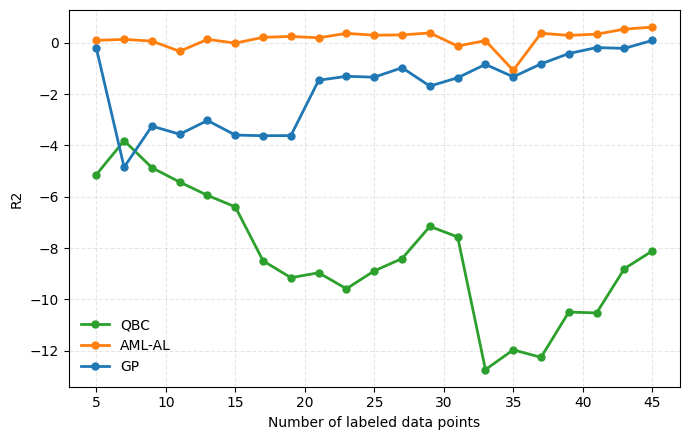

In [9]:
plot_metric("fea_2", "r2")

## FEA +2 | MAE

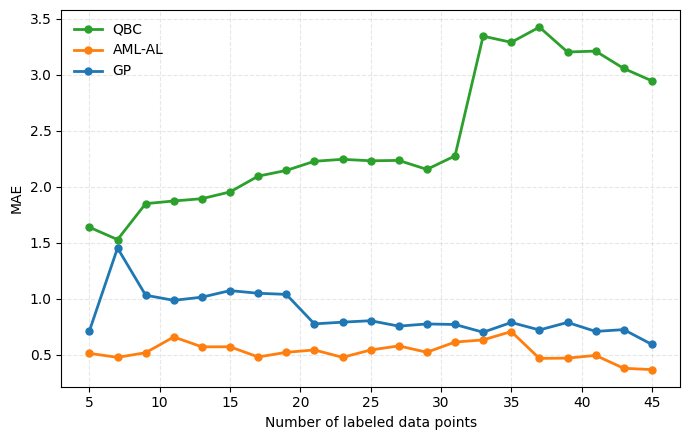

In [10]:
plot_metric("fea_2", "mae")

## FEA +2 | RMSE

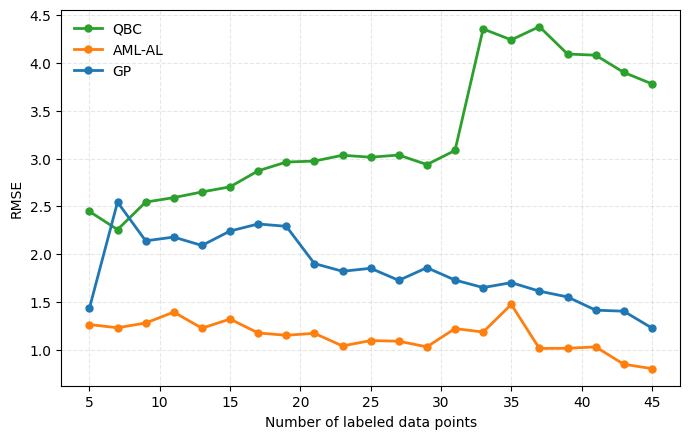

In [11]:
plot_metric("fea_2", "rmse")

## FEA +5 | R2

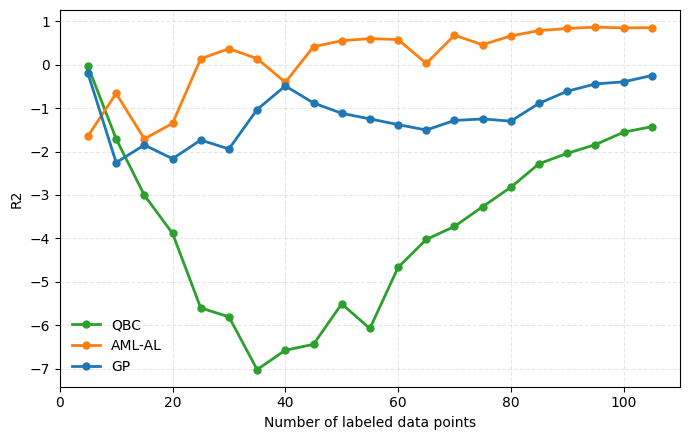

In [12]:
plot_metric("fea_5", "r2")

## FEA +5 | MAE

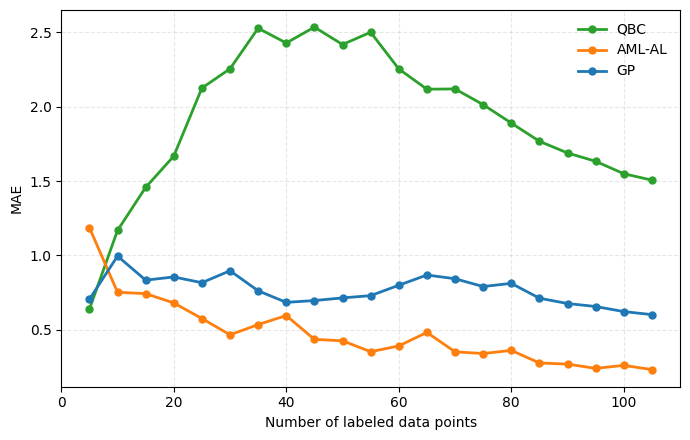

In [13]:
plot_metric("fea_5", "mae")

## FEA +5 | RMSE

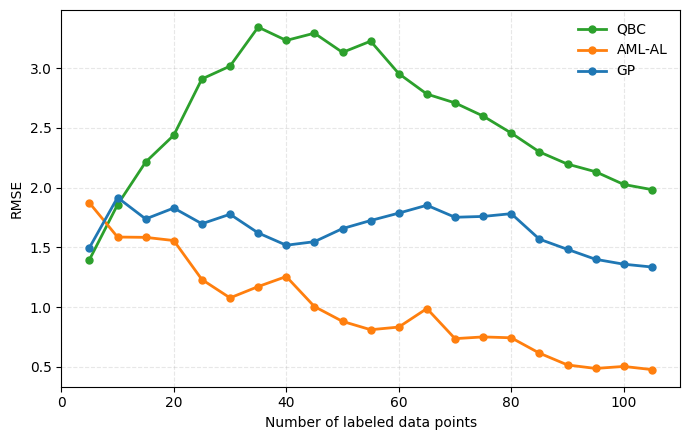

In [14]:
plot_metric("fea_5", "rmse")

## FEA +10 | R2

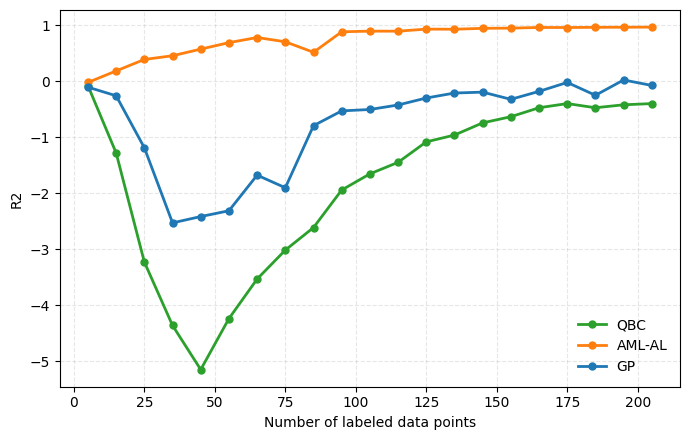

In [15]:
plot_metric("fea_10", "r2")

## FEA +10 | MAE

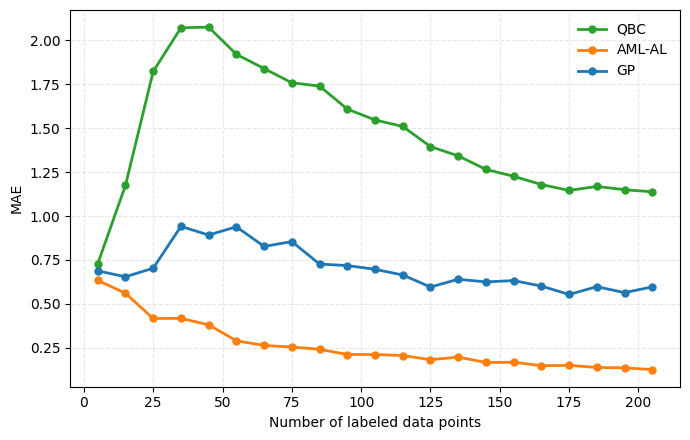

In [16]:
plot_metric("fea_10", "mae")

## FEA +10 | RMSE

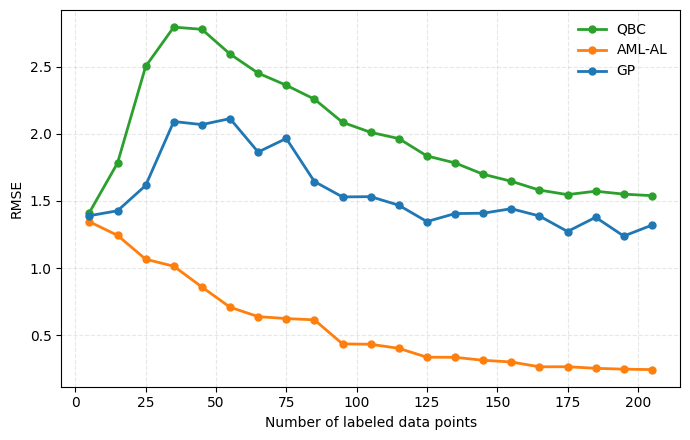

In [17]:
plot_metric("fea_10", "rmse")

## PAN +2 | R2

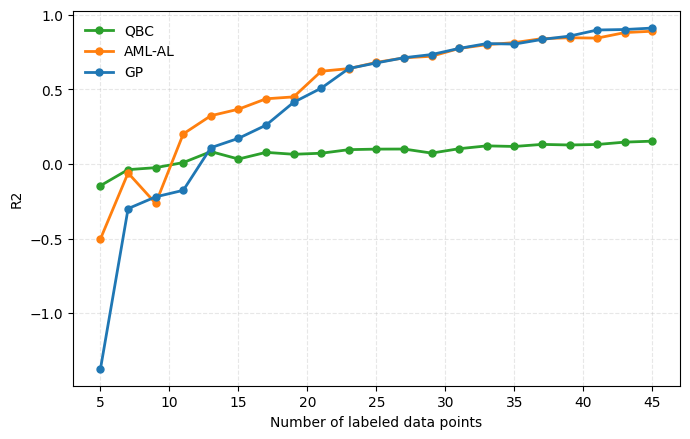

In [18]:
plot_metric("pan_2", "r2")

## PAN +2 | MAE

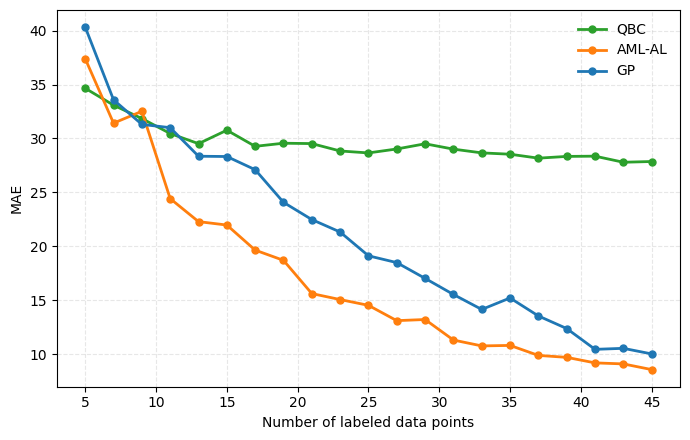

In [19]:
plot_metric("pan_2", "mae")

## PAN +2 | RMSE

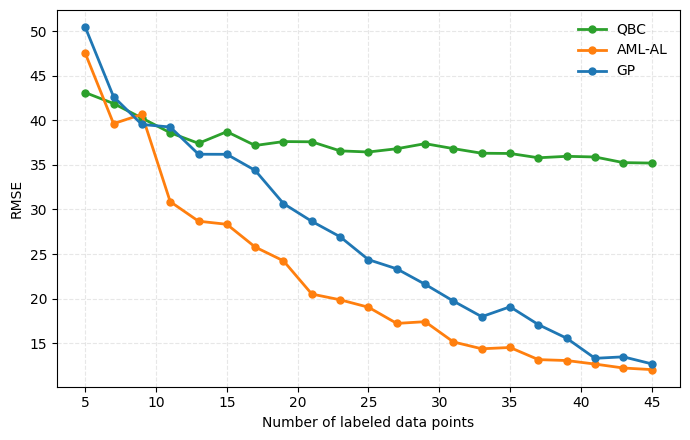

In [20]:
plot_metric("pan_2", "rmse")

## PAN +5 | R2

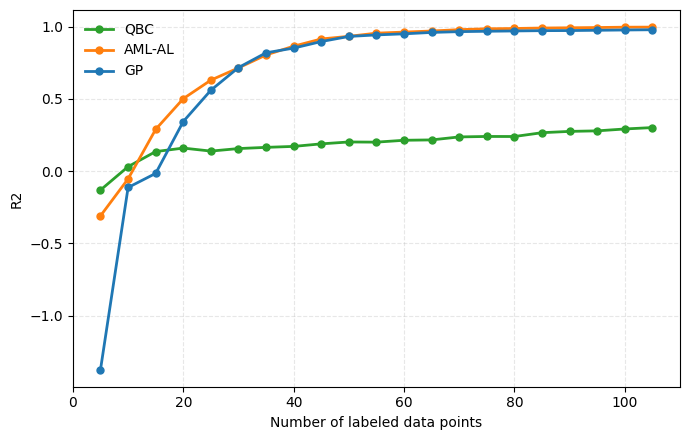

In [21]:
plot_metric("pan_5", "r2")

## PAN +5 | MAE

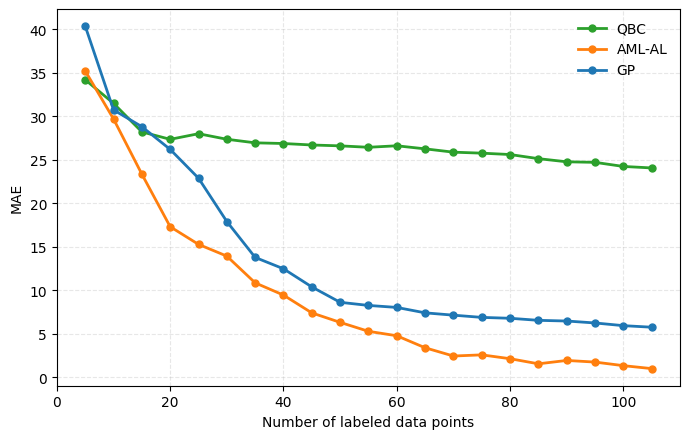

In [22]:
plot_metric("pan_5", "mae")

## PAN +5 | RMSE

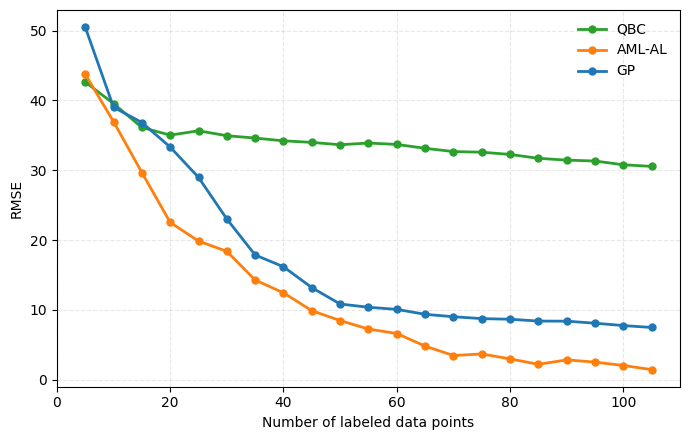

In [23]:
plot_metric("pan_5", "rmse")

## TRC +5 | R2

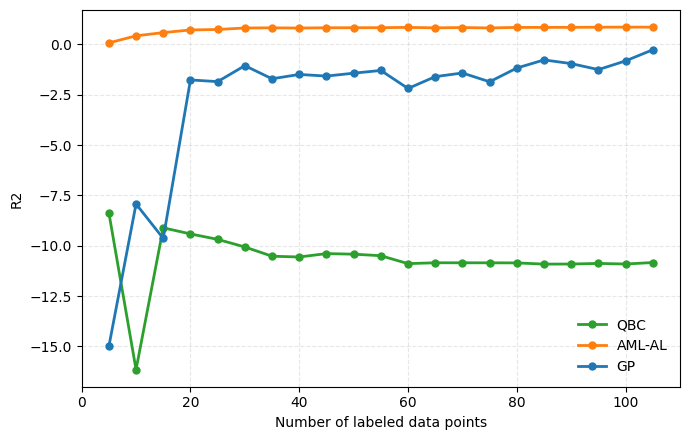

In [24]:
plot_metric("trc_5", "r2")

## TRC +5 | MAE

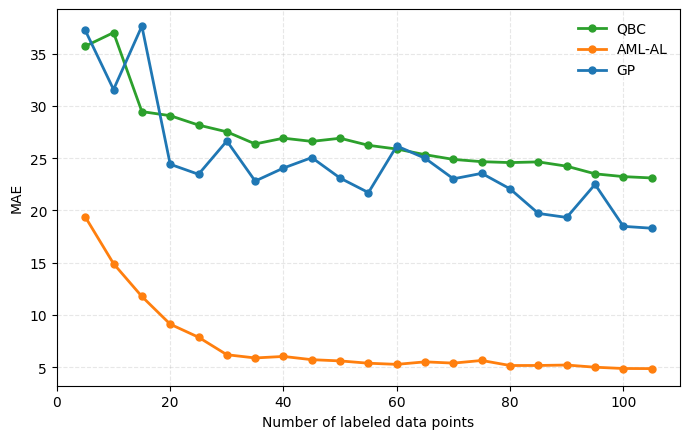

In [25]:
plot_metric("trc_5", "mae")

## TRC +5 | RMSE

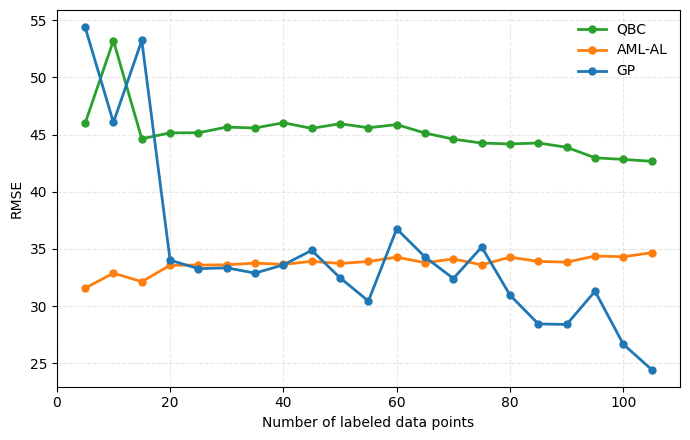

In [26]:
plot_metric("trc_5", "rmse")